## Modeling

In this section, we train and evaluate machine learning models.

Models used:
- Logistic Regression (baseline model)
- Random Forest (non-linear model)

Evaluation metrics:
- Accuracy
- ROC-AUC
- Confusion Matrix

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("credit_feature_engineered.csv")

print("Shape:", df.shape)
df.head()

Shape: (30000, 19)


,limit_bal,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_bill,avg_payment,avg_delay,delay_count,sex_2,education_2,education_3,education_4,marriage_2,marriage_3
0,20000,24,2,2,-1,-1,-2,-2,1,1284.000000,114.833333,-0.333333,2,True,True,False,False,False,False
1,120000,26,-1,2,0,0,0,2,1,2846.166667,833.333333,0.500000,2,True,True,False,False,True,False
2,90000,34,0,0,0,0,0,0,0,16942.166667,1836.333333,0.000000,0,True,True,False,False,True,False
3,50000,37,0,0,0,0,0,0,0,38555.666667,1398.000000,0.000000,0,True,True,False,False,False,False
4,50000,57,-1,0,-1,0,0,0,0,18223.166667,9841.500000,-0.333333,0,False,True,False,False,False,False


### Define Features and Target

We separate the feature-engineered dataset into:

- **X**: predictor variables  
- **y**: target variable (`default`)

In [5]:
y = df["default"]
X = df.drop(columns=["default"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 18)
y shape: (30000,)


### Train-Test Split

We split the dataset into training and testing sets.

Stratified sampling is used to preserve the class distribution of the target variable.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24000, 18)
Test shape: (6000, 18)


### Feature Scaling

We standardize the features using StandardScaler.

Important:
- Fit scaler only on training data
- Transform both training and testing data

This prevents data leakage.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.05686623, -0.26455769,  1.79331103,  1.78019315,  2.65204636,
         1.91181115,  0.2402604 ,  0.25608731,  1.91467196,  0.1351982 ,
         1.72133328,  2.04043134,  0.80844039,  1.06404707, -0.44069047,
        -0.1278524 ,  0.93494465, -0.11288796],
       [-0.13408117, -0.15580369,  0.90294373, -0.72232368, -0.69764249,
        -1.53082598, -1.5372518 , -1.48996255, -0.7112067 , -0.53223878,
        -1.00549757,  0.10594025,  0.80844039, -0.93980805, -0.44069047,
        -0.1278524 ,  0.93494465, -0.11288796],
       [-1.21509034,  1.58426024,  0.90294373,  1.78019315,  0.13977972,
         0.19049259,  0.2402604 ,  0.25608731, -0.57524846, -0.46518545,
         0.69877171,  0.75077061, -1.23694958,  1.06404707, -0.44069047,
        -0.1278524 , -1.06958203, -0.11288796],
       [ 0.40642341, -0.69957367,  0.01257644,  0.1118486 ,  0.13977972,
         0.19049259,  0.2402604 ,  0.25608731,  2.24429029,  0.17220189,
         0.18749092, -0.53889011,  0.80844039, -0.939

### Logistic Regression

We train Logistic Regression as a baseline model.

This model is simple, interpretable, and performs well with scaled data.

In [11]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Logistic Regression Predictions

We generate:
- predicted class labels
- predicted probabilities

These will be used for evaluation.

In [13]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

### Logistic Regression Evaluation

We evaluate the model using:
- Accuracy
- ROC-AUC
- Confusion Matrix
- Classification Report

In [15]:
print("Logistic Regression Results:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:

Accuracy: 0.8093333333333333
ROC-AUC: 0.7400452276711554

Confusion Matrix:
 [[4473  200]
 [ 944  383]]

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.66      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000



### Logistic Regression Interpretation

The model achieves an accuracy of ~81% and ROC-AUC of ~0.74.

Key observations:

- The model performs very well in identifying **non-defaulters (class 0)**:
  - High recall (0.96)
  - Most non-defaulters are correctly classified

- However, performance on **defaulters (class 1)** is weak:
  - Low recall (0.29)
  - Many actual defaulters are misclassified as non-defaulters

- From the confusion matrix:
  - False negatives (944) are high → risky customers are missed

Conclusion:

Although overall accuracy is high, the model struggles to detect defaulters, which is critical in credit risk problems.

This highlights the impact of class imbalance and suggests the need for more powerful models or techniques to improve recall for defaulters.

---
### Random Forest

Random Forest is a powerful ensemble model that can capture non-linear relationships.

It is expected to perform better than Logistic Regression.

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Random Forest Predictions

We generate predictions and probabilities for evaluation.

In [20]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

### Random Forest Evaluation

We evaluate the model using:
- Accuracy
- ROC-AUC
- Confusion Matrix
- Classification Report

In [22]:
print("Random Forest Results:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:

Accuracy: 0.8133333333333334
ROC-AUC: 0.7527577897430945

Confusion Matrix:
 [[4401  272]
 [ 848  479]]

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



### Random Forest Interpretation

The Random Forest model shows improved performance compared to Logistic Regression.

Key observations:

- Accuracy (~81%) is similar to Logistic Regression
- ROC-AUC (~0.75) is higher, indicating better overall discrimination

Performance on defaulters (class 1):

- Recall improved from **0.29 → 0.36**
- F1-score improved from **0.40 → 0.46**

From the confusion matrix:
- False negatives reduced (944 → 848)
- More defaulters are correctly identified

Conclusion:

Random Forest performs better at identifying defaulters due to its ability to capture non-linear relationships.  
However, recall is still relatively low, indicating room for improvement.

---
### Model Comparison

| Metric            | Logistic Regression | Random Forest |
|------------------|-------------------|--------------|
| Accuracy         | 0.81              | 0.81         |
| ROC-AUC          | 0.74              | 0.75         |
| Recall (Default) | 0.29              | 0.36         |
| F1-score         | 0.40              | 0.46         |

### Key Takeaways

- Random Forest outperforms Logistic Regression in detecting defaulters  
- Behavioral features (repayment delays) play a critical role in prediction  
- Accuracy alone is misleading due to class imbalance  
- Recall for defaulters is the most important metric  

### Final Conclusion

Feature engineering significantly improved model performance.  
However, further improvements (e.g., class balancing or threshold tuning) may be needed to better detect high-risk customers.

### Feature Importance (Random Forest)

This plot shows which features contribute most to model predictions.

It helps interpret which factors influence default risk.

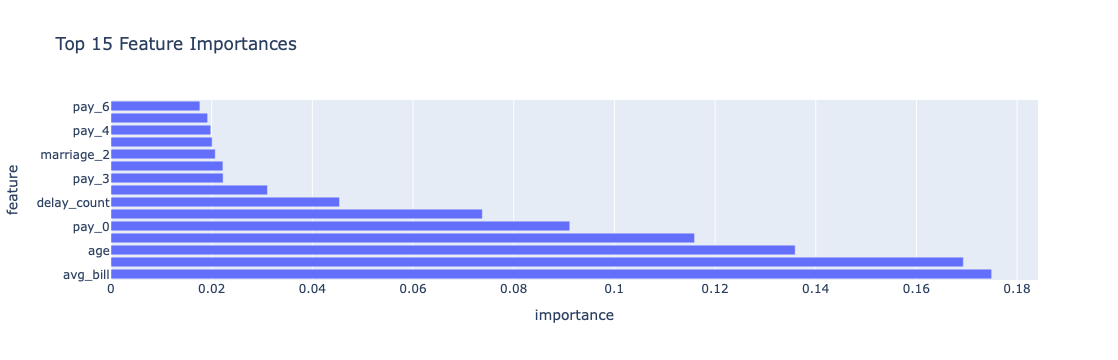

In [26]:
import plotly.express as px
import pandas as pd

# Get feature importance
importances = rf_model.feature_importances_

feature_names = X.columns

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
fig = px.bar(
    feat_df.head(15),
    x="importance",
    y="feature",
    orientation="h",
    title="Top 15 Feature Importances"
)

fig.show()

### Feature Importance Interpretation

The Random Forest model highlights that financial and behavioral features are the most important predictors of default.

- **avg_bill** is the most important feature, indicating that higher spending is strongly associated with default risk.
- **pay_0 (recent repayment status)** is highly influential, showing that recent behavior is a key signal.
- **delay_count**, an engineered feature, also shows strong importance, confirming that frequent delays increase default likelihood.
- **age** contributes meaningfully, suggesting demographic patterns in repayment behavior.

Overall, **recent repayment behavior and spending patterns dominate prediction**, while older repayment history and some demographic features have lower impact.

### Handling Class Imbalance (Class Weight)

The dataset is imbalanced, with fewer defaulters (class 1).

To address this, we assign higher weight to the minority class using `class_weight="balanced"`.

This helps improve recall for default prediction.

In [29]:
from sklearn.linear_model import LogisticRegression

log_model_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model_bal.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [30]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

y_pred_bal = log_model_bal.predict(X_test_scaled)
y_prob_bal = log_model_bal.predict_proba(X_test_scaled)[:, 1]

print("Balanced Logistic Regression Results:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))

Balanced Logistic Regression Results:

Accuracy: 0.762
ROC-AUC: 0.7433593326056095

Confusion Matrix:
 [[3828  845]
 [ 583  744]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



### Model Comparison

We compare all models based on key metrics:

- Accuracy
- ROC-AUC
- Precision (Default)
- Recall (Default)
- F1-score (Default)

This helps identify the best model for predicting defaulters.

### ROC Curve Comparison

The ROC curve compares model performance across different thresholds.

A higher curve (closer to top-left) indicates better discrimination ability.

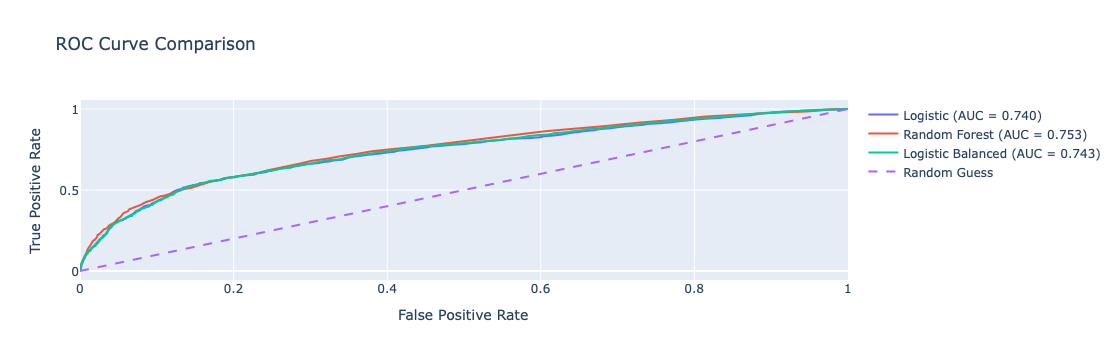

In [33]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)

# Compute AUC
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_bal = auc(fpr_bal, tpr_bal)

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_log, y=tpr_log,
    mode='lines',
    name=f'Logistic (AUC = {auc_log:.3f})'
))

fig.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {auc_rf:.3f})'
))

fig.add_trace(go.Scatter(
    x=fpr_bal, y=tpr_bal,
    mode='lines',
    name=f'Logistic Balanced (AUC = {auc_bal:.3f})'
))

# Diagonal line (random model)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random Guess',
    line=dict(dash='dash')
))

fig.update_layout(
    title="ROC Curve Comparison",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

fig.show()

### ROC Curve Interpretation

All models perform significantly better than random guessing, with AUC values between 0.74 and 0.75.

- Random Forest achieves the highest AUC, indicating the best overall ability to distinguish between defaulters and non-defaulters.
- Balanced Logistic Regression performs similarly in terms of AUC, but provides better recall for defaulters.
- Baseline Logistic Regression performs slightly worse overall.

Although Random Forest has the best overall discrimination, **Balanced Logistic Regression is preferred in this case**, as it better identifies defaulters, which is more critical in credit risk applications.

In [54]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Function to extract metrics
def get_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1-score (1)": report["1"]["f1-score"]
    }

# Collect results
results = []

# Logistic Regression (baseline)
results.append({
    "Model": "Logistic Regression",
    **get_metrics(y_test, y_pred_log, y_prob_log)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    **get_metrics(y_test, y_pred_rf, y_prob_rf)
})

# Balanced Logistic Regression
results.append({
    "Model": "Logistic (Balanced)",
    **get_metrics(y_test, y_pred_bal, y_prob_bal)
})

# Create DataFrame
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,ROC-AUC,Precision (1),Recall (1),F1-score (1)
0,Logistic Regression,0.809333,0.740045,0.656947,0.288621,0.401047
1,Random Forest,0.813333,0.752758,0.637816,0.360965,0.461020
2,Logistic (Balanced),0.762000,0.743359,0.468219,0.560663,0.510288


### Final Model Comparison

The comparison reveals that accuracy alone is not a reliable metric due to class imbalance.

- Baseline Logistic Regression and Random Forest achieve high accuracy (~81%) but suffer from poor recall for defaulters.
- Balanced Logistic Regression significantly improves recall (from 0.29 to 0.56), meaning it detects more default cases.
- Although accuracy decreases slightly, the improvement in recall and F1-score makes it more suitable for credit risk prediction.

In real-world scenarios, missing a defaulter is more costly than incorrectly flagging a non-defaulter. Therefore, **Balanced Logistic Regression is the preferred model**.